# Donor Churn Predictor
**IS 455 INTEX Project — Donor & Support Domain**

| | |
|---|---|
| **Paradigm** | Predictive (Binary Classification) |
| **Sprint Rule** | Problems first, deployment second, quality last |
| **Target** | `supporters.status == "Inactive"` (churned donor) |
| **Primary Metrics** | ROC-AUC · Recall · F1 |
| **Feature Framework** | RFM (Recency, Frequency, Monetary) + Demographics |


## 1. Problem Framing

### Business Problem
This non-profit depends **entirely on donations** to fund its safehouse operations. Donor
acquisition is expensive; retaining existing donors is far cheaper. The founders need an
**early-warning system** that flags donors who are drifting toward lapsing — so the outreach
team can personalize re-engagement before the relationship is lost.

### Why Predictive, Not Explanatory
This pipeline follows **Paradigm B: Predictive Modeling**. The goal is a *ranked list* of
donors most likely to churn so outreach staff can prioritize their limited time. We are NOT
trying to prove that recency *causes* churn — we want to accurately score risk. Complex,
less-interpretable models are acceptable if they improve out-of-sample accuracy.

### Target Variable Definition
We use `supporters.status` as the binary target:

| Value | Target | Interpretation |
|---|---|---|
| `"Inactive"` | **1** | Donor has lapsed / churned |
| `"Active"` | **0** | Donor is still engaged |

**Why `status` over a recency cutoff?** The `status` field reflects an organizational judgment
(case managers have marked these donors inactive) rather than an arbitrary time threshold.
Using recency alone as a target would make the Recency feature a trivially direct predictor —
a near-certain leakage scenario.

**Leakage risk:** `status` is the target — it must be completely dropped from the feature set.
Any field that encodes the act of deactivation (e.g., `deactivated_at`, `reason_for_lapse`)
would also be pure leakage and must be excluded.

### Feature Framework: RFM
Donor churn modeling has a rich industry precedent using **RFM analysis**:
- **Recency (R):** How recently did the donor last give? Stale donors are at highest risk.
- **Frequency (F):** How many times have they given? High frequency implies engagement.
- **Monetary (M):** How much have they given in total, on average, and is the trend up or down?

We extend RFM with behavioral signals (`pct_recurring`, `avg_days_between_donations`)
and categorical demographics (`acquisition_channel`, `supporter_type`, `relationship_type`).

### Who Cares and Why
- **Outreach coordinators:** Need a ranked at-risk list each week to prioritize calls/emails
- **Executive leadership:** Needs to forecast donation revenue risk and retention ROI
- **The mission:** Every retained major donor directly funds more safehouse capacity

### Metric Priority
Class imbalance expected (~25-30% churned). Asymmetric error costs:
- **False Positive** (flag active donor as at-risk): Mild — unnecessary outreach, small waste
- **False Negative** (miss a churning donor): **High cost** — lost revenue, potentially lost relationship

Prioritize: **Recall** → **F1** → **ROC-AUC** → **Log Loss**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    log_loss, precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay, f1_score,
)
from sklearn.inspection import permutation_importance
import joblib, json, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

import sklearn; print(f"sklearn {sklearn.__version__}")
print("All libraries loaded.")


sklearn 1.8.0
All libraries loaded.


## 2. Data Acquisition, Preparation & Exploration

> **Production swap-in:** When the Supabase/PostgreSQL database is live, replace the synthetic
> data block with the SQLAlchemy queries below. All feature engineering code is identical.
>
> ```python
> import os
> from sqlalchemy import create_engine
> engine = create_engine(os.environ["DATABASE_URL"])
> with engine.connect() as conn:
>     df_supporters = pd.read_sql("SELECT * FROM lighthouse_supporters", conn)
>     df_donations  = pd.read_sql("SELECT * FROM lighthouse_donations",  conn)
> ```
>
> **Note on JSONB schema:** In production, `lighthouse_supporters` and `lighthouse_donations`
> store their fields inside a `data jsonb` column. You will need to normalize the `data` dict:
> ```python
> df_supporters = pd.concat(
>     [df_supporters[['supporter_id']], df_supporters['data'].apply(pd.Series)], axis=1
> )
> ```


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYNTHETIC DATA GENERATION
# A shared latent `loyalty` score drives realistic correlations across tables.
# Remove this block and use the DB queries above in production.
# ─────────────────────────────────────────────────────────────────────────────
SNAPSHOT_DATE = pd.Timestamp('2026-04-07')   # "today" — used for recency calculations
N = 500
loyalty = np.random.normal(0, 1, N)

# ── supporters ───────────────────────────────────────────────────────────────
# Churned donors have lower loyalty scores
status_raw = loyalty + np.random.normal(0, 0.7, N)
status_arr = np.where(status_raw < -0.2, 'Inactive', 'Active')

df_supporters = pd.DataFrame({
    'supporter_id':     range(1, N + 1),
    'acquisition_channel': np.random.choice(
        ['Online', 'Event', 'Referral', 'Direct Mail', 'Social Media'],
        N, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'supporter_type':   np.random.choice(
        ['Individual', 'Corporate', 'Foundation'],
        N, p=[0.70, 0.20, 0.10]),
    'relationship_type': np.where(
        loyalty > 1.0,
        np.random.choice(['Major Donor', 'Regular'], 1, p=[0.4, 0.6])[0],
        np.random.choice(['One-time', 'Regular', 'Major Donor'],
                         N, p=[0.45, 0.40, 0.15])),
    # TARGET — will be binarized; must NOT appear in features
    'status':           status_arr,
    # date_joined — known at intake, safe to use for tenure calculation
    'date_joined':      pd.to_datetime('2020-01-01') + pd.to_timedelta(
                            np.random.randint(0, 4 * 365, N), unit='D'),
})

# ── donations ────────────────────────────────────────────────────────────────
# Loyal donors: more donations, more recent, higher amounts, more recurring
# Churned donors: few/old donations, low amounts, no recurring
donation_rows = []
for sid, loy in zip(range(1, N + 1), loyalty):
    # Number of donations: Poisson rate driven by loyalty
    n_don = np.random.poisson(max(0.3, 3.0 + loy * 1.5))
    if n_don == 0:
        continue  # some donors never donated — pure leakage-free churn signal via recency
    # Base date: churned donors' last donation is older
    days_ago_last = int(np.clip(180 - loy * 90 + np.random.normal(0, 60), 10, 900))
    # Spread donations backward from last donation date
    last_date = SNAPSHOT_DATE - pd.Timedelta(days=days_ago_last)
    date_offsets = np.sort(np.random.randint(0, max(1, days_ago_last * (n_don + 1) // 2), n_don))
    dates = [last_date - pd.Timedelta(days=int(o)) for o in reversed(date_offsets)]
    # PHP amounts — log-normal, loyal donors donate more
    base_amount = np.exp(7.5 + loy * 0.6)   # exp(7.5) ≈ PHP 1,800
    amounts = np.abs(np.random.normal(base_amount, base_amount * 0.4, n_don)).clip(100, 500_000)
    # Add slight downward trend for churned donors
    if loy < 0:
        trend_factor = np.linspace(1.2, 0.8, n_don)
        amounts = amounts * trend_factor
    # Recurring: loyal donors more likely to have recurring donations
    is_recurring = np.random.binomial(1, np.clip(0.35 + loy * 0.15, 0.05, 0.90), n_don)
    for date, amt, rec in zip(dates, amounts, is_recurring):
        donation_rows.append({
            'supporter_id': sid,
            'donation_date': date,
            'amount':        round(float(amt), 2),
            'is_recurring':  bool(rec),
        })

df_donations = pd.DataFrame(donation_rows)
df_donations['donation_date'] = pd.to_datetime(df_donations['donation_date'])

print("Synthetic data generated:")
print(f"  supporters : {len(df_supporters):>5} rows")
print(f"  donations  : {len(df_donations):>5} rows")
print()
print("Status distribution:")
print(df_supporters['status'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print(f"Supporters with zero donations: "
      f"{N - df_donations['supporter_id'].nunique()} "
      f"(treated as maximum-recency churn risk)")


Synthetic data generated:
  supporters :   500 rows
  donations  :  1492 rows

Status distribution:
status
Active     58.0000
Inactive   42.0000

Supporters with zero donations: 55 (treated as maximum-recency churn risk)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — RFM + demographics, all aggregated per supporter_id
# ─────────────────────────────────────────────────────────────────────────────

# ── Recency ──────────────────────────────────────────────────────────────────
recency_df = (
    df_donations
    .groupby('supporter_id')['donation_date']
    .max()
    .reset_index()
    .rename(columns={'donation_date': 'last_donation_date'})
)
recency_df['days_since_last_donation'] = (
    (SNAPSHOT_DATE - recency_df['last_donation_date']).dt.days
)

first_df = (
    df_donations
    .groupby('supporter_id')['donation_date']
    .min()
    .reset_index()
    .rename(columns={'donation_date': 'first_donation_date'})
)
first_df['days_since_first_donation'] = (
    (SNAPSHOT_DATE - first_df['first_donation_date']).dt.days
)

# ── Frequency ─────────────────────────────────────────────────────────────────
freq_df = (
    df_donations
    .groupby('supporter_id')
    .agg(total_donations=('amount', 'count'),
         pct_recurring   =('is_recurring', 'mean'))
    .reset_index()
)

# ── Monetary ──────────────────────────────────────────────────────────────────
monetary_df = (
    df_donations
    .groupby('supporter_id')
    .agg(total_amount=('amount', 'sum'),
         avg_amount   =('amount', 'mean'),
         max_amount   =('amount', 'max'))
    .reset_index()
)

# ── Amount trend (slope of amounts over time per donor) ───────────────────────
def _amount_trend(amounts_series: pd.Series) -> float:
    vals = amounts_series.values
    if len(vals) < 2:
        return 0.0
    x = np.arange(len(vals), dtype=float)
    return float(np.polyfit(x, vals, 1)[0])

df_donations_sorted = df_donations.sort_values(['supporter_id', 'donation_date'])
trend_df = (
    df_donations_sorted
    .groupby('supporter_id')['amount']
    .apply(_amount_trend)
    .reset_index()
)
trend_df.columns = ['supporter_id', 'amount_trend']

# ── Average days between donations ───────────────────────────────────────────
def _avg_gap(dates_series: pd.Series) -> float:
    if len(dates_series) < 2:
        return np.nan
    sorted_d = dates_series.sort_values()
    return float(sorted_d.diff().dt.days.dropna().mean())

gap_df = (
    df_donations
    .groupby('supporter_id')['donation_date']
    .apply(_avg_gap)
    .reset_index()
)
gap_df.columns = ['supporter_id', 'avg_days_between_donations']

# ── Merge all features ────────────────────────────────────────────────────────
# Base: supporters demographics — DROP 'status' (the target) here
SUPP_FEATURE_COLS = ['supporter_id', 'acquisition_channel', 'supporter_type',
                     'relationship_type', 'date_joined']

df_model = (
    df_supporters[SUPP_FEATURE_COLS]
    .merge(recency_df[['supporter_id', 'days_since_last_donation']], on='supporter_id', how='left')
    .merge(first_df[['supporter_id',  'days_since_first_donation']], on='supporter_id', how='left')
    .merge(freq_df,      on='supporter_id', how='left')
    .merge(monetary_df,  on='supporter_id', how='left')
    .merge(trend_df,     on='supporter_id', how='left')
    .merge(gap_df,       on='supporter_id', how='left')
    .merge(df_supporters[['supporter_id', 'status']], on='supporter_id', how='left')
)

# Supporter tenure from date_joined
df_model['days_since_joined'] = (SNAPSHOT_DATE - df_model['date_joined']).dt.days

# Fill 0-donation supporters: max recency sentinel, zero for counts/amounts
df_model['days_since_last_donation'] = df_model['days_since_last_donation'].fillna(9999)
df_model['days_since_first_donation'] = df_model['days_since_first_donation'].fillna(9999)
df_model['total_donations'] = df_model['total_donations'].fillna(0)
df_model['pct_recurring']   = df_model['pct_recurring'].fillna(0)
df_model['total_amount']    = df_model['total_amount'].fillna(0)
df_model['avg_amount']      = df_model['avg_amount'].fillna(0)
df_model['max_amount']      = df_model['max_amount'].fillna(0)
df_model['amount_trend']    = df_model['amount_trend'].fillna(0)
# avg_days_between_donations stays NaN for 0-1 donation donors — imputed in pipeline

# Binary target
df_model['target'] = (df_model['status'] == 'Inactive').astype(int)

FEATURE_COLS = [
    'days_since_last_donation', 'days_since_first_donation', 'days_since_joined',
    'total_donations', 'pct_recurring', 'avg_days_between_donations',
    'total_amount', 'avg_amount', 'max_amount', 'amount_trend',
    'acquisition_channel', 'supporter_type', 'relationship_type',
]

print("Feature matrix assembled:")
print(f"  Shape : {df_model.shape}")
print(f"  Target: {df_model['target'].mean():.1%} positive (Inactive / churned)")
print()
print(f"{'Feature':<35} {'Nulls':>6}  Dtype")
print('-' * 55)
for col in FEATURE_COLS:
    print(f"  {col:<33} {df_model[col].isnull().sum():>5}  {df_model[col].dtype}")


Feature matrix assembled:
  Shape : (500, 17)
  Target: 42.0% positive (Inactive / churned)

Feature                              Nulls  Dtype
-------------------------------------------------------
  days_since_last_donation              0  float64
  days_since_first_donation             0  float64
  days_since_joined                     0  int64
  total_donations                       0  float64
  pct_recurring                         0  float64
  avg_days_between_donations          142  float64
  total_amount                          0  float64
  avg_amount                            0  float64
  max_amount                            0  float64
  amount_trend                          0  float64
  acquisition_channel                   0  object
  supporter_type                        0  object
  relationship_type                     0  object


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LEAKAGE AUDIT
# ─────────────────────────────────────────────────────────────────────────────
LEAKAGE_COLS = ['status', 'date_joined']  # status = target; date_joined replaced by tenure feature

print('=' * 65)
print('LEAKAGE AUDIT REPORT — Donor Churn Predictor')
print('=' * 65)

print('\n[DROPPED — confirmed target / leakage fields]')
for col in LEAKAGE_COLS:
    present = col in FEATURE_COLS
    flag    = '!!! IN FEATURES — FIX NOW' if present else 'OK  Correctly excluded from FEATURE_COLS'
    print(f'  [{flag}]  {col}')

print('\n[RETAINED — verified pre-outcome features only]')
justifications = {
    'days_since_last_donation':  'Recency — observable at any point in time',
    'days_since_first_donation': 'Relationship age — from first donation date',
    'days_since_joined':         'Tenure — from date_joined (sign-up date)',
    'total_donations':           'Frequency — lifetime count of donation events',
    'pct_recurring':             'Recurring habit — fraction of recurring donations',
    'avg_days_between_donations':'Cadence — average gap between consecutive donations',
    'total_amount':              'Monetary — lifetime giving total (PHP)',
    'avg_amount':                'Monetary — average donation size (PHP)',
    'max_amount':                'Monetary — largest single donation (PHP)',
    'amount_trend':              'Monetary trend — slope of donation amounts over time',
    'acquisition_channel':       'Channel — how the donor was acquired',
    'supporter_type':            'Type — Individual / Corporate / Foundation',
    'relationship_type':         'Tier — One-time / Regular / Major Donor',
}
for col, reason in justifications.items():
    print(f'  [OK ]  {col:<38} {reason}')

leakage_found = any(col in FEATURE_COLS for col in LEAKAGE_COLS)
print()
if leakage_found:
    raise RuntimeError('AUDIT FAILED — leakage detected. Remove flagged columns.')
print('AUDIT PASSED — no leakage detected. Safe to model.')


LEAKAGE AUDIT REPORT — Donor Churn Predictor

[DROPPED — confirmed target / leakage fields]
  [OK  Correctly excluded from FEATURE_COLS]  status
  [OK  Correctly excluded from FEATURE_COLS]  date_joined

[RETAINED — verified pre-outcome features only]
  [OK ]  days_since_last_donation               Recency — observable at any point in time
  [OK ]  days_since_first_donation              Relationship age — from first donation date
  [OK ]  days_since_joined                      Tenure — from date_joined (sign-up date)
  [OK ]  total_donations                        Frequency — lifetime count of donation events
  [OK ]  pct_recurring                          Recurring habit — fraction of recurring donations
  [OK ]  avg_days_between_donations             Cadence — average gap between consecutive donations
  [OK ]  total_amount                           Monetary — lifetime giving total (PHP)
  [OK ]  avg_amount                             Monetary — average donation size (PHP)
  [OK ]  ma

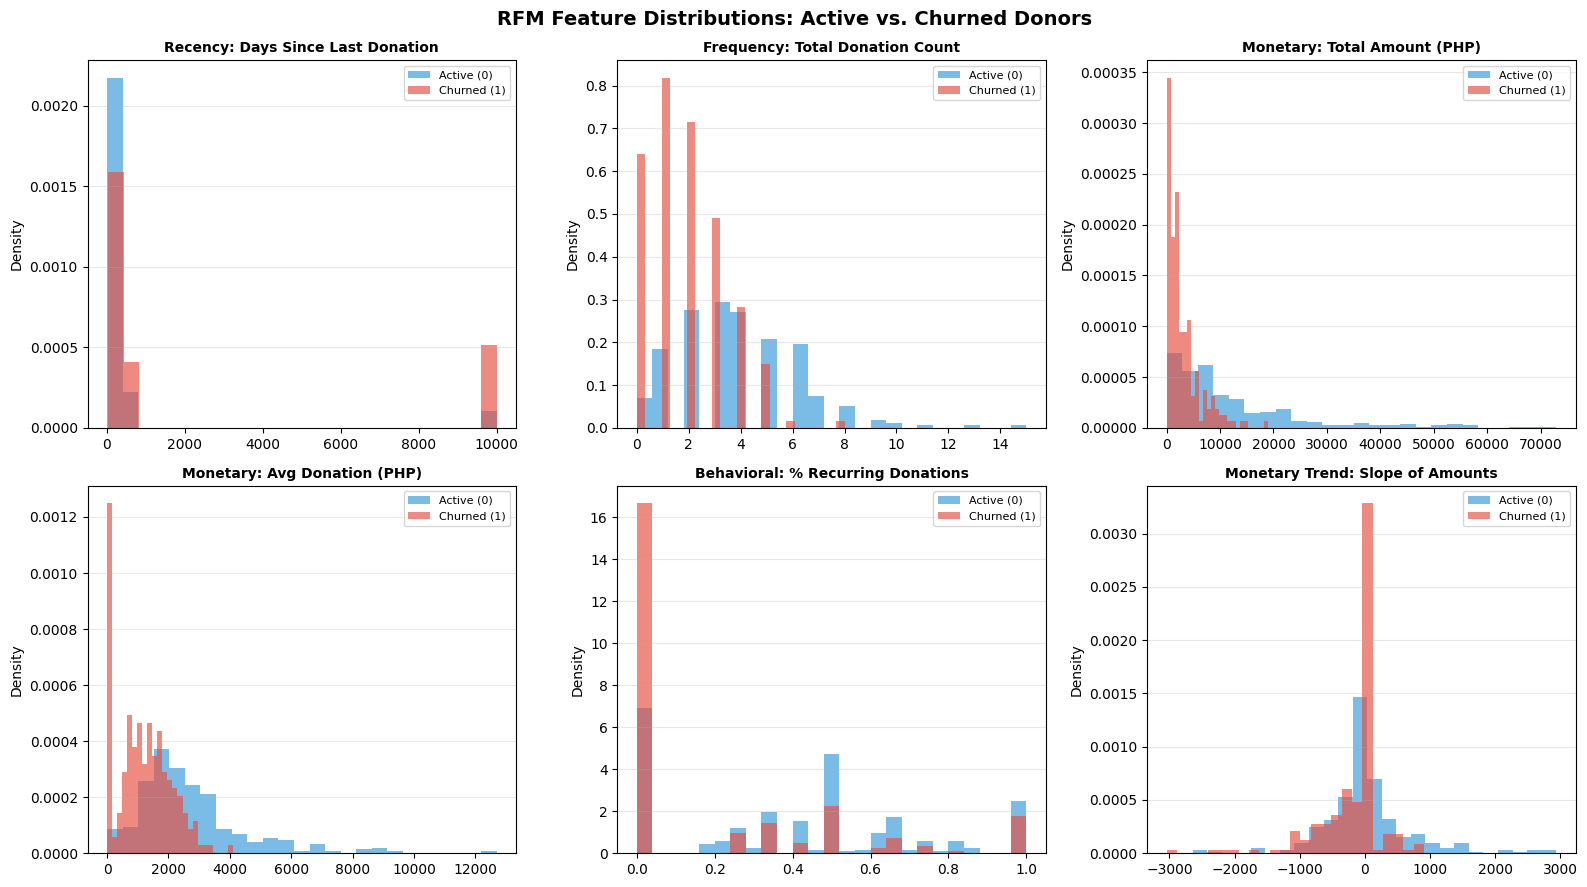

Saved: churn_eda_rfm_distributions.png


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: RFM feature distributions by churn outcome
# ─────────────────────────────────────────────────────────────────────────────
CHURNED     = df_model['target'] == 1
NOT_CHURNED = df_model['target'] == 0

PLOT_FEATURES = [
    ('days_since_last_donation',  'Recency: Days Since Last Donation'),
    ('total_donations',           'Frequency: Total Donation Count'),
    ('total_amount',              'Monetary: Total Amount (PHP)'),
    ('avg_amount',                'Monetary: Avg Donation (PHP)'),
    ('pct_recurring',             'Behavioral: % Recurring Donations'),
    ('amount_trend',              'Monetary Trend: Slope of Amounts'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('RFM Feature Distributions: Active vs. Churned Donors', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes.flatten(), PLOT_FEATURES):
    vals_no  = df_model.loc[NOT_CHURNED, col].dropna()
    vals_yes = df_model.loc[CHURNED, col].dropna()
    ax.hist(vals_no,  bins=25, alpha=0.65, label='Active (0)',  color='#3498db', density=True)
    ax.hist(vals_yes, bins=25, alpha=0.65, label='Churned (1)', color='#e74c3c', density=True)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('churn_eda_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_eda_rfm_distributions.png")


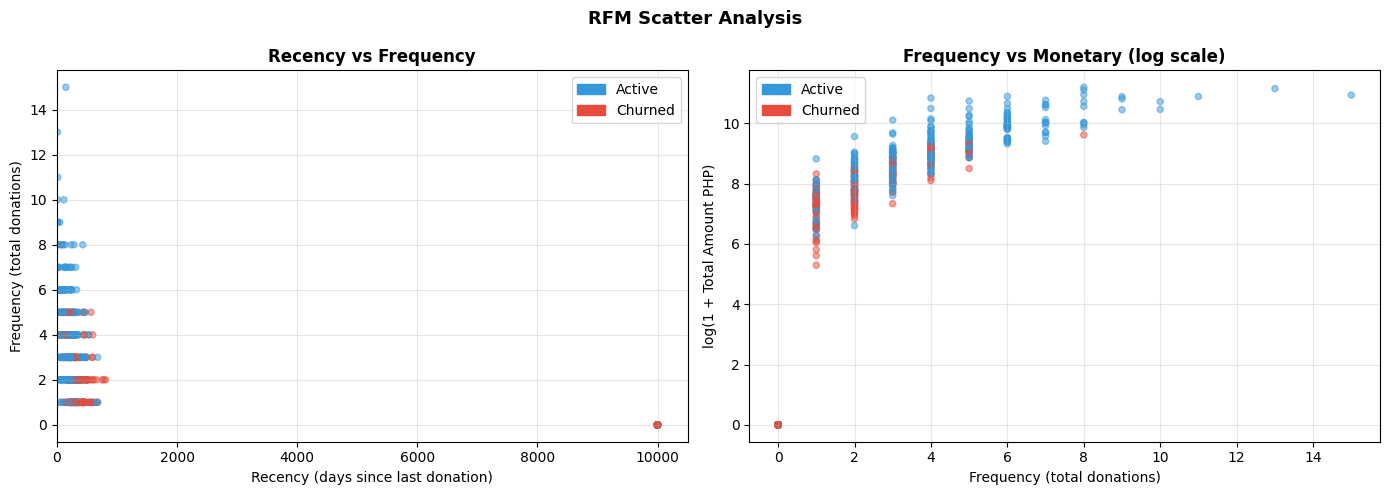

Saved: churn_eda_rfm_scatter.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: RFM scatter — Recency vs Frequency coloured by target
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RFM Scatter Analysis', fontsize=13, fontweight='bold')

colors = df_model['target'].map({0: '#3498db', 1: '#e74c3c'})

# Recency vs Frequency
axes[0].scatter(df_model['days_since_last_donation'],
                df_model['total_donations'],
                c=colors, alpha=0.5, s=20)
axes[0].set_xlabel('Recency (days since last donation)')
axes[0].set_ylabel('Frequency (total donations)')
axes[0].set_title('Recency vs Frequency', fontweight='bold')
axes[0].set_xlim(left=0)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#3498db', label='Active'),
                         Patch(color='#e74c3c', label='Churned')])
axes[0].grid(alpha=0.3)

# Frequency vs log(Total Amount)
log_amt = np.log1p(df_model['total_amount'])
axes[1].scatter(df_model['total_donations'], log_amt, c=colors, alpha=0.5, s=20)
axes[1].set_xlabel('Frequency (total donations)')
axes[1].set_ylabel('log(1 + Total Amount PHP)')
axes[1].set_title('Frequency vs Monetary (log scale)', fontweight='bold')
axes[1].legend(handles=[Patch(color='#3498db', label='Active'),
                         Patch(color='#e74c3c', label='Churned')])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('churn_eda_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: churn_eda_rfm_scatter.png")


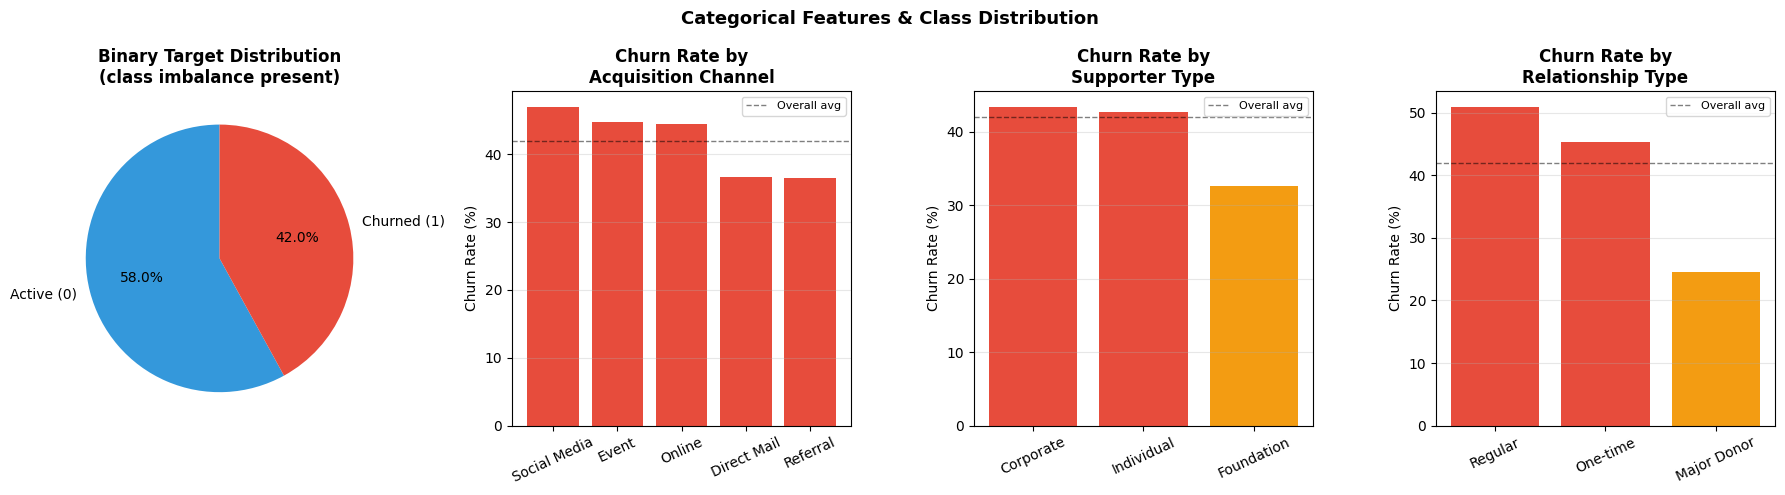

Class imbalance ratio: 1.38:1  (active:churned)

Churn rate by relationship_type:
relationship_type
Major Donor   24.6000
One-time      45.4000
Regular       50.9000


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Categorical breakdown + class distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Categorical Features & Class Distribution', fontsize=13, fontweight='bold')

# 1. Class distribution pie
target_counts = df_model['target'].value_counts()
axes[0].pie(target_counts.values,
            labels=['Active (0)', 'Churned (1)'],
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Binary Target Distribution\n(class imbalance present)', fontweight='bold')

# 2-4. Churn rate by categorical feature
for ax, col in zip(axes[1:], ['acquisition_channel', 'supporter_type', 'relationship_type']):
    churn_rate = df_model.groupby(col)['target'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=['#e74c3c' if v > 0.35 else '#f39c12' if v > 0.20 else '#3498db'
                         for v in churn_rate.values])
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by\n{col.replace("_", " ").title()}', fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(df_model['target'].mean() * 100, color='black', linestyle='--',
               alpha=0.5, linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('churn_eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = target_counts[0] / target_counts[1]
print(f'Class imbalance ratio: {ratio:.2f}:1  (active:churned)')
print()
print('Churn rate by relationship_type:')
print(df_model.groupby('relationship_type')['target'].mean().mul(100).round(1).to_string())


## 3. Modeling & Feature Selection

### Pipeline Architecture

```
ColumnTransformer
  ├── numerical   →  SimpleImputer(median)       →  StandardScaler
  └── categorical →  SimpleImputer(most_frequent) →  OneHotEncoder(handle_unknown='ignore')
          │
          └──>  GradientBoostingClassifier   [primary]
                RandomForestClassifier        [baseline — with class_weight='balanced']
```

### Why Gradient Boosting for RFM Churn?
RFM features are highly skewed (log-normal donation amounts, Poisson frequency) and have
non-linear interaction effects — e.g., a donor with high frequency but extreme recency is
very different from one with both high. Tree-based ensembles naturally handle these
non-linearities without requiring log transforms.

### Feature Selection
All 13 features are included. In Paradigm B, we do **not** remove correlated features
(e.g., `total_amount` and `avg_amount` are correlated, but both carry predictive signal).
The ensemble handles multicollinearity by distributing splits across correlated features.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING PIPELINE + TRAIN/TEST SPLIT + MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
CAT_FEATURES = ['acquisition_channel', 'supporter_type', 'relationship_type']
NUM_FEATURES = [c for c in FEATURE_COLS if c not in CAT_FEATURES]

X = df_model[FEATURE_COLS].copy()
y = df_model['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} rows  |  churn rate: {y_train.mean():.1%}')
print(f'Test : {len(X_test)} rows  |  churn rate: {y_test.mean():.1%}')

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES),
], remainder='drop')

# Primary model
gbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        min_samples_split=20, min_samples_leaf=10,
        subsample=0.80, random_state=42,
    )),
])

# Baseline — RF with balanced class weights to handle imbalance
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1,
    )),
])

print('\nTraining Gradient Boosting...')
gbm_pipeline.fit(X_train, y_train)
print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)
print('Both models trained.')


Train: 400 rows  |  churn rate: 42.0%
Test : 100 rows  |  churn rate: 42.0%

Training Gradient Boosting...
Training Random Forest...


Both models trained.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION (training set only)
# ─────────────────────────────────────────────────────────────────────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'precision', 'recall']

print('5-Fold Stratified CV Results')
print('=' * 55)
for name, pipe in [('Gradient Boosting', gbm_pipeline), ('Random Forest', rf_pipeline)]:
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'\n{name}:')
    for m in scoring:
        scores = res[f'test_{m}']
        print(f'  {m:<12}  {scores.mean():.4f} +/- {scores.std():.4f}')


5-Fold Stratified CV Results



Gradient Boosting:
  roc_auc       0.7582 +/- 0.0475
  f1            0.6131 +/- 0.0567
  precision     0.6232 +/- 0.0576
  recall        0.6064 +/- 0.0726



Random Forest:
  roc_auc       0.7940 +/- 0.0424
  f1            0.6543 +/- 0.0516
  precision     0.6686 +/- 0.0744
  recall        0.6481 +/- 0.0703


## 4. Evaluation & Interpretation

Models are evaluated on the **held-out test set (20%)** — never seen during training or CV.

### Business Cost of Errors

| Error | Scenario | Cost to Organization |
|---|---|---|
| **False Positive** | Flag active donor as at-risk → unnecessary personalized outreach | Low — small staff time cost; may even strengthen relationship |
| **False Negative** | Miss a churning donor → no intervention made | **High** — lost donation revenue; potentially permanent relationship loss |

We accept lower precision in exchange for higher recall. The Precision-Recall curve is used
to select an operating threshold that maximizes recall without flooding staff with unworkable
at-risk lists. A threshold calibrated at best-F1 is our default starting point.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TEST SET METRICS
# ─────────────────────────────────────────────────────────────────────────────
y_pred_gbm = gbm_pipeline.predict(X_test)
y_prob_gbm = gbm_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf  = rf_pipeline.predict(X_test)
y_prob_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

for name, y_pred, y_prob in [
    ('GRADIENT BOOSTING', y_pred_gbm, y_prob_gbm),
    ('RANDOM FOREST',     y_pred_rf,  y_prob_rf),
]:
    print('=' * 60)
    print(f'{name} — Test Set')
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
    print(f'  Log Loss : {log_loss(y_test, y_prob):.4f}')
    print()


GRADIENT BOOSTING — Test Set
              precision    recall  f1-score   support

      Active       0.72      0.76      0.74        58
     Churned       0.64      0.60      0.62        42

    accuracy                           0.69       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.69      0.69      0.69       100

  ROC-AUC  : 0.7611
  Log Loss : 0.6174

RANDOM FOREST — Test Set
              precision    recall  f1-score   support

      Active       0.75      0.76      0.75        58
     Churned       0.66      0.64      0.65        42

    accuracy                           0.71       100
   macro avg       0.70      0.70      0.70       100
weighted avg       0.71      0.71      0.71       100

  ROC-AUC  : 0.8005
  Log Loss : 0.5250



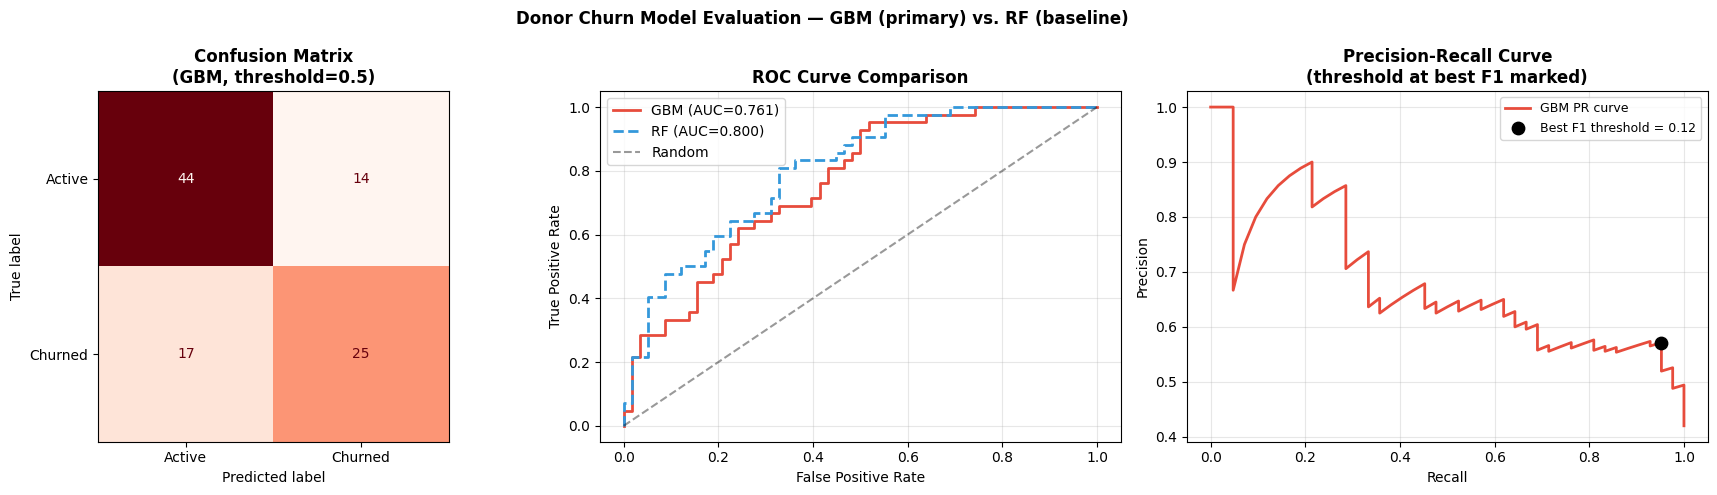

Best F1 threshold : 0.115
  Precision : 0.571
  Recall    : 0.952


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION PLOTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Donor Churn Model Evaluation — GBM (primary) vs. RF (baseline)',
             fontsize=12, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gbm)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Active', 'Churned']
                       ).plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Confusion Matrix\n(GBM, threshold=0.5)', fontweight='bold')

# 2. ROC Curves
for nm, y_prob, color, ls in [
    ('GBM', y_prob_gbm, '#e74c3c', '-'),
    ('RF',  y_prob_rf,  '#3498db', '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=f'{nm} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve + optimal F1 threshold
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob_gbm)
f1_arr     = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)
best_idx   = int(f1_arr.argmax())
best_thresh = float(thresholds_arr[best_idx])

axes[2].plot(recall_arr, precision_arr, color='#e74c3c', lw=2, label='GBM PR curve')
axes[2].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='black', zorder=5, s=80,
                label=f'Best F1 threshold = {best_thresh:.2f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve\n(threshold at best F1 marked)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('churn_eval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best F1 threshold : {best_thresh:.3f}')
print(f'  Precision : {precision_arr[best_idx]:.3f}')
print(f'  Recall    : {recall_arr[best_idx]:.3f}')


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE MODEL ARTIFACTS
# ─────────────────────────────────────────────────────────────────────────────
churn_metadata = {
    'model_name':           'donor_churn_gbm',
    'model_version':        '1.0.0',
    'target':               'supporters.status == Inactive',
    'feature_columns':      FEATURE_COLS,
    'numerical_features':   NUM_FEATURES,
    'categorical_features': CAT_FEATURES,
    'roc_auc_test':         round(float(roc_auc_score(y_test, y_prob_gbm)), 4),
    'f1_test':              round(float(f1_score(y_test, y_pred_gbm)), 4),
    'best_threshold':       round(best_thresh, 4),
    'trained_on':           '2026-04-07',
    'currency':             'PHP',
}

joblib.dump(gbm_pipeline, 'donor_churn_model.joblib')
with open('donor_churn_metadata.json', 'w') as f:
    json.dump(churn_metadata, f, indent=2)

print('Model saved   : donor_churn_model.joblib')
print('Metadata saved: donor_churn_metadata.json')
print()
for k, v in churn_metadata.items():
    if k != 'feature_columns':
        print(f'  {k:<25}: {v}')


Model saved   : donor_churn_model.joblib
Metadata saved: donor_churn_metadata.json

  model_name               : donor_churn_gbm
  model_version            : 1.0.0
  target                   : supporters.status == Inactive
  numerical_features       : ['days_since_last_donation', 'days_since_first_donation', 'days_since_joined', 'total_donations', 'pct_recurring', 'avg_days_between_donations', 'total_amount', 'avg_amount', 'max_amount', 'amount_trend']
  categorical_features     : ['acquisition_channel', 'supporter_type', 'relationship_type']
  roc_auc_test             : 0.7611
  f1_test                  : 0.6173
  best_threshold           : 0.1154
  trained_on               : 2026-04-07
  currency                 : PHP


## 5. Causal and Relationship Analysis

> **Paradigm B caveat:** This is a strictly predictive pipeline. All patterns described here
> are **correlational**, not causal. High recency *predicts* churn — it does not *cause* it.
> A donor who hasn't given recently may be experiencing financial hardship, life changes, or
> simply waiting to be re-engaged. Confounders not captured (campaign quality, economic
> conditions, relationship with staff) likely drive much of the underlying behavior.

### What Feature Importances Reveal About Data Structure

**Gini importances** from the GBM reflect average impurity reduction per feature across all
splits. They tend to favor continuous, high-cardinality features.

**Permutation importances** (test set) measure actual ROC-AUC degradation when a feature is
randomly shuffled — more reliable for comparing features of different types.

### Interpretive Hypotheses (Correlation, Not Causation)

| Feature Pattern | Likely Data Mechanism |
|---|---|
| High `days_since_last_donation` strongly predicts churn | Recency is the canonical RFM signal — donors who haven't given in 12+ months are behaviorally disengaged |
| Low `total_donations` (frequency) → higher churn | One-time donors are inherently less committed than repeat donors; no habit formed |
| Negative `amount_trend` → higher churn | Declining donation amounts may signal decreasing capacity or decreasing engagement — a leading indicator |
| Low `pct_recurring` → higher churn | Recurring donations require an explicit commitment decision; their absence reflects no durable intention |
| `relationship_type == "One-time"` → highest churn rate | Structural — one-time donors were never enrolled in a retention relationship |
| `acquisition_channel` variation | Some channels (e.g., Event) may attract one-off impulse donors vs. Online channels that attract committed supporters — data-dependent |

**Honest limitation:** The `days_since_last_donation` feature is almost a proxy for the target
in some organizational definitions of "inactive." In production with real data, verify that
the `status` label update date is *not* correlated with donation recency in a circular way
(e.g., if staff systematically mark donors inactive only 12 months after their last gift,
recency becomes a near-perfect predictor by construction — which is valid but worth naming).


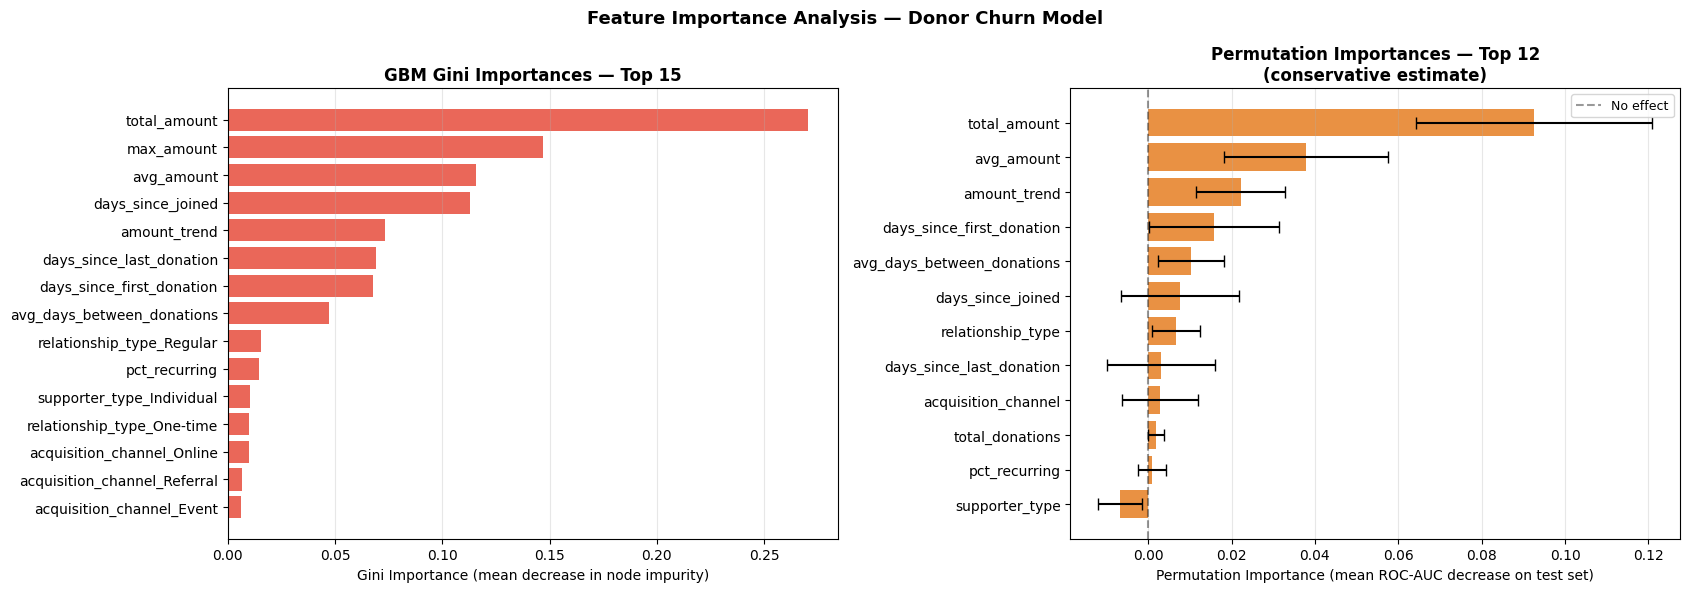

Top 10 features by permutation importance:
                   feature  mean_imp  std_imp
              total_amount    0.0926   0.0283
                avg_amount    0.0379   0.0196
              amount_trend    0.0222   0.0107
 days_since_first_donation    0.0158   0.0156
avg_days_between_donations    0.0102   0.0079
         days_since_joined    0.0077   0.0142
         relationship_type    0.0067   0.0058
  days_since_last_donation    0.0031   0.0129
       acquisition_channel    0.0028   0.0091
           total_donations    0.0019   0.0019


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCES — Gini + Permutation
# ─────────────────────────────────────────────────────────────────────────────
ohe_names = (
    gbm_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(CAT_FEATURES)
    .tolist()
)
all_names = NUM_FEATURES + ohe_names
gini_imp  = gbm_pipeline.named_steps['classifier'].feature_importances_

gini_df = (
    pd.DataFrame({'feature': all_names, 'importance': gini_imp})
    .sort_values('importance', ascending=False)
    .head(15)
)

perm = permutation_importance(
    gbm_pipeline, X_test, y_test,
    n_repeats=25, random_state=42, scoring='roc_auc', n_jobs=-1
)
perm_df = (
    pd.DataFrame({
        'feature':  FEATURE_COLS,
        'mean_imp': perm.importances_mean,
        'std_imp':  perm.importances_std,
    })
    .sort_values('mean_imp', ascending=False)
    .head(12)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Feature Importance Analysis — Donor Churn Model', fontsize=13, fontweight='bold')

ax1.barh(gini_df['feature'][::-1], gini_df['importance'][::-1],
         color='#e74c3c', alpha=0.85)
ax1.set_xlabel('Gini Importance (mean decrease in node impurity)')
ax1.set_title('GBM Gini Importances — Top 15', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(perm_df['feature'][::-1], perm_df['mean_imp'][::-1],
         xerr=perm_df['std_imp'][::-1], color='#e67e22', alpha=0.85, capsize=4)
ax2.axvline(0, color='black', linestyle='--', alpha=0.4, label='No effect')
ax2.set_xlabel('Permutation Importance (mean ROC-AUC decrease on test set)')
ax2.set_title('Permutation Importances — Top 12\n(conservative estimate)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('churn_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by permutation importance:')
print(perm_df[['feature', 'mean_imp', 'std_imp']].head(10).to_string(index=False))


## 6. Deployment Notes

### Architecture

```
[React Admin Portal — "Donors & Contributions" page]
      |
      | GET /api/donors/at-risk?threshold=0.55&limit=25
      v
[.NET 10 Minimal API]   <──  appsettings.json (ChurnService:BaseUrl)
      |
      | POST /predict-batch  (JSON array of supporter feature payloads)
      v
[Python FastAPI — donor_churn_service.py  (port 8002)]
      |
      | joblib.load()
      v
[donor_churn_model.joblib]
```

### Batch Prediction Design
Unlike the single-resident Reintegration endpoint, this endpoint is a **batch scorer**:
the .NET API queries all supporter features in one SQL (JOIN with donation aggregations),
sends the full list to the Python service's `/predict-batch` endpoint, then filters and
sorts the results before returning them. This avoids N HTTP calls.

### Component Files

| File | Purpose |
|---|---|
| `ml-pipelines/donor_churn_model.joblib` | Trained sklearn pipeline |
| `ml-pipelines/donor_churn_metadata.json` | Feature list, threshold, version |
| `ml-pipelines/donor_churn_service.py` | FastAPI microservice (port 8002) |
| `deployment/DonorChurnEndpoint.cs` | .NET 10 batch prediction endpoint |
| `deployment/AtRiskDonors.tsx` | React "At-Risk Donors Alert" component |

### Startup

```bash
pip install fastapi uvicorn joblib scikit-learn pandas numpy
uvicorn donor_churn_service:app --host 0.0.0.0 --port 8002
```

### Request / Response Schema

```json
POST /predict-batch
[
  {
    "supporter_id": 42,
    "days_since_last_donation": 410,
    "days_since_first_donation": 800,
    "days_since_joined": 900,
    "total_donations": 3,
    "pct_recurring": 0.0,
    "avg_days_between_donations": 195.0,
    "total_amount": 4500.00,
    "avg_amount": 1500.00,
    "max_amount": 2000.00,
    "amount_trend": -150.0,
    "acquisition_channel": "Event",
    "supporter_type": "Individual",
    "relationship_type": "One-time"
  }
]

GET /api/donors/at-risk?threshold=0.55&limit=25
[
  {
    "supporter_id": 42,
    "churn_probability": 0.8734,
    "risk_tier": "High Risk",
    "threshold_used": 0.55,
    "top_risk_signals": ["high_recency", "zero_recurring", "negative_trend"]
  }
]
```


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICTION FUNCTION + SMOKE TESTS
# Mirrors the logic in donor_churn_service.py for local verification.
# ─────────────────────────────────────────────────────────────────────────────
def predict_churn(supporter_features: dict,
                  metadata_path: str = 'donor_churn_metadata.json',
                  model_path: str = 'donor_churn_model.joblib') -> dict:
    with open(metadata_path) as f:
        meta = json.load(f)
    model     = joblib.load(model_path)
    threshold = meta['best_threshold']
    df_in     = pd.DataFrame([supporter_features])[meta['feature_columns']]
    prob      = float(model.predict_proba(df_in)[0, 1])
    prediction = 'At Risk' if prob >= threshold else 'Stable'
    if prob >= 0.75:
        risk_tier = 'High Risk'
    elif prob >= threshold:
        risk_tier = 'Moderate Risk'
    else:
        risk_tier = 'Low Risk'
    # Simple top-signal extraction
    risk_signals = []
    if supporter_features.get('days_since_last_donation', 0) > 365:
        risk_signals.append('high_recency')
    if supporter_features.get('pct_recurring', 1) == 0:
        risk_signals.append('zero_recurring')
    if supporter_features.get('amount_trend', 0) < 0:
        risk_signals.append('negative_trend')
    if supporter_features.get('total_donations', 999) <= 1:
        risk_signals.append('one_time_only')
    return {
        'supporter_id':       supporter_features.get('supporter_id'),
        'churn_probability':  round(prob, 4),
        'prediction':         prediction,
        'risk_tier':          risk_tier,
        'threshold_used':     round(threshold, 4),
        'top_risk_signals':   risk_signals,
    }


HIGH_CHURN = {
    'supporter_id': 42,
    'days_since_last_donation': 450, 'days_since_first_donation': 600,
    'days_since_joined': 700,        'total_donations': 2,
    'pct_recurring': 0.0,            'avg_days_between_donations': 150.0,
    'total_amount': 3000.0,          'avg_amount': 1500.0,
    'max_amount': 2000.0,            'amount_trend': -200.0,
    'acquisition_channel': 'Event',  'supporter_type': 'Individual',
    'relationship_type': 'One-time',
}

LOW_CHURN = {
    'supporter_id': 99,
    'days_since_last_donation': 18,  'days_since_first_donation': 1100,
    'days_since_joined': 1200,       'total_donations': 14,
    'pct_recurring': 0.85,           'avg_days_between_donations': 30.0,
    'total_amount': 95000.0,         'avg_amount': 6785.0,
    'max_amount': 25000.0,           'amount_trend': 450.0,
    'acquisition_channel': 'Referral', 'supporter_type': 'Corporate',
    'relationship_type': 'Major Donor',
}

for label, ex in [('HIGH churn risk', HIGH_CHURN), ('LOW churn risk', LOW_CHURN)]:
    result = predict_churn(ex)
    print(f'--- {label} ---')
    for k, v in result.items():
        print(f'  {k:<28}: {v}')
    print()

print('Pipeline complete. Model ready for deployment.')


--- HIGH churn risk ---
  supporter_id                : 42
  churn_probability           : 0.4241
  prediction                  : At Risk
  risk_tier                   : Moderate Risk
  threshold_used              : 0.1154
  top_risk_signals            : ['high_recency', 'zero_recurring', 'negative_trend']

--- LOW churn risk ---
  supporter_id                : 99
  churn_probability           : 0.0298
  prediction                  : Stable
  risk_tier                   : Low Risk
  threshold_used              : 0.1154
  top_risk_signals            : []

Pipeline complete. Model ready for deployment.
